# MGTF-423 Professor Pipeline Notebook

Notebook will build features from raw sql data sources, train 3 models, evaluate the models with traditional metrics (AUC / R-Squared), and generate charts.

Runtime ~ 5min 

[GitHub Repo](https://github.com/ryderrhoads/MGTF-423-Final-Project)


## Suggested flow before you run the notebook

### macOS / Linux
```bash
python3 -m venv .venv
source .venv/bin/activate
pip install yfinance pandas sec-edgar-downloader sqlalchemy psycopg2-binary scikit-learn xgboost shap torch transformers python-dotenv numpy requests pypdf matplotlib jupyter ipykernel 
```

### Windows (PowerShell)
```bash
python -m venv .venv
.\.venv\Scripts\Activate.ps1
pip install yfinance pandas sec-edgar-downloader sqlalchemy psycopg2-binary scikit-learn xgboost shap torch transformers python-dotenv numpy requests pypdf matplotlib jupyter ipykernel
```

In [ ]:
import os
from pathlib import Path

# Hardcoded connection string (Obviously in prod I would never do this)
db_url = "postgresql://professor:{pass}@{ip}:5432/classdb?sslmode=require"
os.environ["DATABASE_URL"] = db_url
os.environ["FEATURE_SOURCE"] = "postgres"


## Embedded build-features 


In [2]:
import os
import numpy as np
import pandas as pd
from sqlalchemy import create_engine


def _norm_ticker(x: str) -> str:
    return str(x).strip().upper().replace('.', '-')


def _forward_fill_last_10k(df: pd.DataFrame, col: str) -> pd.Series:
    form = df.get('form', '').astype(str).str.upper()
    is_10k = form.str.startswith('10-K')
    return df[col].where(is_10k).groupby(df['ticker']).ffill()


def build_features_main() -> pd.DataFrame:
    db_url = os.getenv('DATABASE_URL') or os.getenv('POSTGRES_URL')
    if not db_url:
        raise RuntimeError('DATABASE_URL must be set in .env')

    eng = create_engine(db_url)

    fin = pd.read_sql('SELECT * FROM financials', eng)
    fin['ticker'] = fin['ticker'].map(_norm_ticker)
    fin['filed_date'] = pd.to_datetime(fin['filed_date'], errors='coerce')
    fin = fin.dropna(subset=['ticker', 'filed_date']).sort_values(['ticker', 'filed_date', 'accession']).reset_index(drop=True)

    q = (
        'SELECT ticker, accession, filed_date, section, score, num_units, '
        'positive_count, negative_count, neutral_count, score_std '
        'FROM finbert_section_scores'
    )
    txt = pd.read_sql(q, eng)
    txt['ticker'] = txt['ticker'].map(_norm_ticker)
    txt['filed_date'] = pd.to_datetime(txt['filed_date'], errors='coerce')
    txt['score_num'] = pd.to_numeric(txt.get('score'), errors='coerce')
    for c in ['num_units','positive_count','negative_count','neutral_count','score_std']:
        txt[c] = pd.to_numeric(txt.get(c), errors='coerce').fillna(0)

    mdna = txt.loc[txt['section'].eq('MD&A')].groupby(['ticker','accession'])['score_num'].mean().rename('mdna_sentiment')
    risk = txt.loc[txt['section'].eq('Risk Factors')].groupby(['ticker','accession'])['score_num'].mean().rename('risk_sentiment')

    t = txt.groupby(['ticker','accession','filed_date'], as_index=False).agg(
        filing_length=('num_units','sum'),
        avg_text_score=('score_num','mean'),
        score_std_mean=('score_std','mean'),
        score_std_max=('score_std','max'),
        positive_count_total=('positive_count','sum'),
        negative_count_total=('negative_count','sum'),
        neutral_count_total=('neutral_count','sum'),
        section_count=('section','nunique'),
        num_units_total=('num_units','sum'),
    )
    t = t.merge(mdna.reset_index(), on=['ticker','accession'], how='left')
    t = t.merge(risk.reset_index(), on=['ticker','accession'], how='left')

    den = (t['positive_count_total'] + t['negative_count_total'] + t['neutral_count_total']).replace(0, np.nan)
    t['positive_ratio'] = t['positive_count_total'] / den
    t['negative_ratio'] = t['negative_count_total'] / den
    t['neutral_ratio'] = t['neutral_count_total'] / den
    t['sentiment_polarity'] = t['positive_ratio'] - t['negative_ratio']
    t['units_per_section'] = t['num_units_total'] / t['section_count'].replace(0, np.nan)

    t = t.sort_values(['ticker','filed_date'])
    t['filing_length_change'] = t.groupby('ticker')['filing_length'].pct_change()
    t['sentiment_change_qoq'] = t.groupby('ticker')['avg_text_score'].diff()

    feat = fin.merge(t, on=['ticker','accession','filed_date'], how='left')
    feat = feat.sort_values(['ticker','filed_date','accession']).reset_index(drop=True)

    for c in ['mdna_sentiment', 'risk_sentiment']:
        if c in feat.columns:
            carry = _forward_fill_last_10k(feat, c)
            feat[c] = pd.to_numeric(feat[c], errors='coerce').where(pd.to_numeric(feat[c], errors='coerce').notna(), carry)

    for col in [
        'mdna_sentiment','risk_sentiment','avg_text_score','filing_length',
        'score_std_mean','score_std_max','positive_ratio','negative_ratio','neutral_ratio',
        'sentiment_polarity','section_count','num_units_total','units_per_section'
    ]:
        if col in feat.columns:
            mu = feat.groupby('form')[col].transform('mean')
            sd = feat.groupby('form')[col].transform('std').replace(0, np.nan)
            feat[f'{col}_form_z'] = ((feat[col]-mu)/sd).fillna(0.0)

    rev = pd.to_numeric(feat.get('revenue'), errors='coerce')
    cogs = pd.to_numeric(feat.get('cogs'), errors='coerce')
    ni = pd.to_numeric(feat.get('net_income'), errors='coerce')
    sgna = pd.to_numeric(feat.get('sgna'), errors='coerce')
    inv = pd.to_numeric(feat.get('inventory'), errors='coerce')
    debt = pd.to_numeric(feat.get('debt'), errors='coerce')
    eq = pd.to_numeric(feat.get('equity'), errors='coerce')

    def r(num, den):
        return pd.to_numeric(num, errors='coerce') / pd.to_numeric(den, errors='coerce').replace(0, np.nan)

    feat['gross_margin'] = r(rev-cogs, rev)
    feat['sales_inventory'] = r(rev, inv)
    feat['debt_equity'] = r(debt, eq)

    for col in ['revenue','gross_margin','net_income','sgna','inventory','sales_inventory']:
        if col in feat.columns:
            feat[f'{col}_change_qoq'] = feat.groupby('ticker')[col].pct_change()
            feat[f'{col}_change_yoy'] = feat.groupby('ticker')[col].pct_change(4)

    feat['net_margin'] = r(ni, rev)
    feat['cogs_margin'] = r(cogs, rev)
    feat['sgna_margin'] = r(sgna, rev)
    feat['inventory_to_equity'] = r(inv, eq)
    feat['debt_to_assets_proxy'] = r(debt, debt + eq)
    feat['equity_to_assets_proxy'] = r(eq, debt + eq)
    feat['gross_profit'] = rev - cogs
    feat['gross_profit_margin'] = r(feat['gross_profit'], rev)
    feat['debt_to_gross_profit'] = r(debt, feat['gross_profit'])
    feat['margin_surprise_proxy'] = feat.get('gross_margin_change_qoq') - feat.get('gross_margin_change_yoy')

    tickers = sorted(set(feat['ticker'].dropna().astype(str)))
    need = sorted(set(tickers + ['SPY','VCR','VDC']))
    md = pd.read_sql(
        'SELECT ticker, date, ret, close, volume FROM market_data_daily WHERE ticker = ANY(%(tickers)s)',
        eng,
        params={'tickers': need}
    )
    md['ticker'] = md['ticker'].map(_norm_ticker)
    md['date'] = pd.to_datetime(md['date'], errors='coerce')
    md['ret'] = pd.to_numeric(md['ret'], errors='coerce')
    md['close'] = pd.to_numeric(md['close'], errors='coerce')
    md['volume'] = pd.to_numeric(md['volume'], errors='coerce')
    md = md.dropna(subset=['date']).sort_values(['ticker','date'])
    md_by = {t: g.reset_index(drop=True) for t,g in md.groupby('ticker')}

    def trailing_compound(df, asof, n):
        if df is None or df.empty or pd.isna(asof):
            return np.nan
        s = pd.to_numeric(df.loc[df['date']<=asof,'ret'], errors='coerce').dropna().tail(n)
        if len(s) < max(2, n//2):
            return np.nan
        return float((1.0+s).prod()-1.0)

    def trailing_vol(df, asof, n):
        if df is None or df.empty or pd.isna(asof):
            return np.nan
        s = pd.to_numeric(df.loc[df['date']<=asof,'ret'], errors='coerce').dropna().tail(n)
        if len(s) < max(2, n//2):
            return np.nan
        return float(s.std(ddof=1)*np.sqrt(252))

    def asof_close(df, asof):
        if df is None or df.empty or pd.isna(asof):
            return np.nan
        z = df.loc[df['date']<=asof]
        if z.empty:
            return np.nan
        return float(z.iloc[-1].get('close', np.nan))

    spy = md_by.get('SPY', pd.DataFrame(columns=['date','ret','close','volume']))
    vcr = md_by.get('VCR', pd.DataFrame(columns=['date','ret','close','volume']))
    vdc = md_by.get('VDC', pd.DataFrame(columns=['date','ret','close','volume']))

    rows=[]
    for r0 in feat.itertuples(index=False):
        tkr = str(getattr(r0,'ticker'))
        d = getattr(r0,'filed_date')
        stock = md_by.get(tkr, pd.DataFrame(columns=['date','ret','close','volume']))
        etf = vdc if str(getattr(r0,'consumer_label', '')).lower()=='consumer_staples' else vcr

        stock20 = trailing_compound(stock,d,20)
        stock60 = trailing_compound(stock,d,60)
        spy20 = trailing_compound(spy,d,20)
        spy60 = trailing_compound(spy,d,60)

        c = asof_close(stock,d)
        high_252 = pd.to_numeric(stock.loc[stock['date']<=d,'close'], errors='coerce').tail(252).max() if not stock.empty else np.nan
        dv20 = np.nan
        tv20 = np.nan
        roll = stock.loc[stock['date']<=d].tail(20)
        if not roll.empty:
            dv20 = float((pd.to_numeric(roll['close'], errors='coerce') * pd.to_numeric(roll['volume'], errors='coerce')).mean())
            tv20 = float(pd.to_numeric(roll['volume'], errors='coerce').mean())

        rows.append({
            'pre_event_runup_5d': trailing_compound(stock,d,5),
            'pre_event_runup_10d': trailing_compound(stock,d,10),
            'pre_event_runup_60d': trailing_compound(stock,d,60),
            'stock_momentum_20d': stock20,
            'stock_momentum_60d': stock60,
            'spy_momentum_20d': spy20,
            'spy_momentum_60d': spy60,
            'etf_momentum_60d': trailing_compound(etf,d,60),
            'stock_vol_20d': trailing_vol(stock,d,20),
            'spy_vol_20d': trailing_vol(spy,d,20),
            'etf_vol_20d': trailing_vol(etf,d,20),
            'relative_strength_20d': stock20-spy20 if pd.notna(stock20) and pd.notna(spy20) else np.nan,
            'relative_strength_60d': stock60-spy60 if pd.notna(stock60) and pd.notna(spy60) else np.nan,
            'etf_relative_strength_20d': trailing_compound(etf,d,20)-spy20 if pd.notna(spy20) else np.nan,
            'etf_relative_strength_60d': trailing_compound(etf,d,60)-spy60 if pd.notna(spy60) else np.nan,
            'stock_20d_excess_return': stock20-spy20 if pd.notna(stock20) and pd.notna(spy20) else np.nan,
            'dollar_volume_20d': dv20,
            'turnover_20d': tv20,
            'high_252d': high_252,
            'distance_to_52w_high': (c/high_252-1.0) if pd.notna(c) and pd.notna(high_252) and high_252 else np.nan,
        })

    out = pd.concat([feat.reset_index(drop=True), pd.DataFrame(rows)], axis=1)
    out['log_dollar_volume_20d'] = np.log1p(np.clip(pd.to_numeric(out.get('dollar_volume_20d'), errors='coerce'), 0, None))
    out['log_market_cap'] = np.log1p(np.clip(pd.to_numeric(out.get('market_cap'), errors='coerce'), 0, None))
    out['filing_month'] = pd.to_datetime(out['filed_date'], errors='coerce').dt.month

    out = out.replace([np.inf, -np.inf], np.nan)
    num_cols=[c for c in out.columns if pd.api.types.is_numeric_dtype(out[c])]
    out[num_cols]=out.groupby('ticker', group_keys=False)[num_cols].ffill()
    for c in num_cols:
        out[c]=out[c].fillna(out[c].median())
    out[num_cols]=out[num_cols].fillna(0.0)

    drop_cols={
        'growth_vs_momentum','inventory_sales_gap','operating_leverage_proxy','debt_equity','debt_equity_slog',
        'sales_inventory_change_qoq','sales_inventory_change_yoy_slog','inventory_buildup','interaction_sentiment_momentum',
        'risk_sentiment_form_z','gross_margin_change_qoq_slog','gross_profit_growth_yoy_slog','growth_to_valuation',
        'gross_margin_change_yoy_slog','inventory_turnover_proxy','sales_inventory_change_qoq_slog','sales_inventory_change_yoy',
        'etf_momentum_20d','gross_margin_change_qoq','acceleration_revenue','revenue_change_qoq_slog','market_cap',
        'dollar_volume_20d','shares_outstanding','cogs','revenue','filing_quarter','filing_length','filing_length_form_z',
        'filing_length_change','mdna_sentiment_form_z','risk_sentiment','mdna_sentiment','avg_text_score_form_z',
        'uncertainty_score_form_z','uncertainty_delta','uncertainty_score',
    }
    out=out.drop(columns=[c for c in drop_cols if c in out.columns], errors='ignore')
    return out


_build_features_fn = build_features_main


## Helper functions 


In [3]:
"""
Train and evaluate models using a time-series split (70/10/20).

Targets:
- Direction of excess return
- Large move indicator
- Magnitude of excess return
"""

from __future__ import annotations

import os
from dataclasses import dataclass
from pathlib import Path
from typing import Tuple

import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.impute import SimpleImputer
# ElasticNet removed from headline runs to keep evaluation lean/defensible.
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    precision_score,
    r2_score,
    recall_score,
    roc_auc_score,
)
# (intentionally removed pipeline-based linear classifier imports)

try:
    from xgboost import XGBClassifier, XGBRegressor
except Exception as e:  # pragma: no cover
    raise SystemExit("xgboost is required. pip install xgboost") from e

try:
    import shap
except Exception:
    shap = None

try:
    from sqlalchemy import create_engine
except Exception:
    create_engine = None


DATA_DIR = Path("data")
FEATURES_PATH = DATA_DIR / "features.csv"
RETURNS_DIR = DATA_DIR / "daily_returns"
IMPORTANCE_DIR = DATA_DIR / "feature_importance"
DATABASE_URL = os.getenv("DATABASE_URL") or os.getenv("POSTGRES_URL")
FEATURES_TABLE = os.getenv("FEATURES_TABLE", "features")


@dataclass
class Split:
    train: pd.DataFrame
    val: pd.DataFrame
    test: pd.DataFrame


def load_returns(ticker: str) -> pd.DataFrame:
    p = RETURNS_DIR / f"{ticker}.csv"
    if not p.exists():
        return pd.DataFrame(columns=["date", "ret"])
    df = pd.read_csv(p)
    if df.empty:
        return pd.DataFrame(columns=["date", "ret"])
    val_col = ticker if ticker in df.columns else df.columns[-1]
    out = pd.DataFrame(
        {
            "date": pd.to_datetime(df["Date"], errors="coerce"),
            "ret": pd.to_numeric(df[val_col], errors="coerce"),
        }
    ).dropna()
    return out.sort_values("date").reset_index(drop=True)


def forward_compound_return(df_ret: pd.DataFrame, asof: pd.Timestamp, horizon: int) -> float | None:
    if df_ret.empty or pd.isna(asof):
        return None
    s = df_ret.loc[df_ret["date"] > asof, "ret"].head(horizon)
    if len(s) < horizon:
        return None
    return float((1.0 + s).prod() - 1.0)


def trailing_vol(df_ret: pd.DataFrame, asof: pd.Timestamp, n: int) -> float | None:
    if df_ret.empty or pd.isna(asof):
        return None
    s = pd.to_numeric(df_ret.loc[df_ret["date"] <= asof, "ret"].tail(n), errors="coerce").dropna()
    if len(s) < max(2, n // 2):
        return None
    return float(s.std(ddof=1))


def forward_vol(df_ret: pd.DataFrame, asof: pd.Timestamp, n: int) -> float | None:
    if df_ret.empty or pd.isna(asof):
        return None
    s = pd.to_numeric(df_ret.loc[df_ret["date"] > asof, "ret"].head(n), errors="coerce").dropna()
    if len(s) < max(2, n // 2):
        return None
    return float(s.std(ddof=1))


def trailing_beta(stock_ret: pd.DataFrame, spy_ret: pd.DataFrame, asof: pd.Timestamp, n: int = 252) -> float | None:
    """OLS beta from trailing daily returns aligned by date. Returns None if insufficient overlap."""
    if stock_ret.empty or spy_ret.empty or pd.isna(asof):
        return None
    s = stock_ret.loc[stock_ret["date"] <= asof].tail(n).set_index("date")["ret"]
    m = spy_ret.loc[spy_ret["date"] <= asof].tail(n).set_index("date")["ret"]
    both = pd.DataFrame({"s": s, "m": m}).dropna()
    if len(both) < max(60, n // 4):
        return None
    cov = both["s"].cov(both["m"])
    var = both["m"].var()
    if var == 0 or not np.isfinite(var):
        return None
    beta = cov / var
    return float(np.clip(beta, -5.0, 5.0))


def add_targets(df: pd.DataFrame, horizons: tuple[int, ...] = (1, 5, 20)) -> pd.DataFrame:
    out = df.copy()
    out["filed_date"] = pd.to_datetime(out["filed_date"], errors="coerce")

    tickers = sorted(set(out["ticker"].dropna().astype(str)))
    ret_cache = {t: load_returns(t) for t in tickers}
    spy = load_returns("SPY")

    targets = {h: [] for h in horizons}
    vol_exp_10d = []
    betas_used = []

    for _, r in out.iterrows():
        t = str(r.get("ticker", ""))
        d = r.get("filed_date")
        stock = ret_cache.get(t, pd.DataFrame(columns=["date", "ret"]))

        # Volatility expansion target: vol_10d_after / vol_20d_before
        v_after_10 = forward_vol(stock, d, 10)
        v_before_20 = trailing_vol(stock, d, 20)
        if v_after_10 is None or v_before_20 in (None, 0) or not np.isfinite(v_before_20):
            vol_exp_10d.append(np.nan)
        else:
            vol_exp_10d.append(float(v_after_10 / v_before_20))

        # Beta-adjusted excess return: r_stock - beta * r_spy
        beta = trailing_beta(stock, spy, d, n=252)
        if beta is None:
            beta = 1.0  # fallback to market-neutral if insufficient history
        betas_used.append(beta)

        for h in horizons:
            r_stock = forward_compound_return(stock, d, h)
            r_spy = forward_compound_return(spy, d, h)
            if r_stock is None or r_spy is None:
                targets[h].append(np.nan)
            else:
                targets[h].append(r_stock - beta * r_spy)

    out["target_vol_expansion_10d"] = vol_exp_10d
    out["target_beta_used"] = betas_used

    for h in horizons:
        ex_col = f"target_excess_{h}d"
        out[ex_col] = targets[h]
        out[f"target_cls_up_{h}d"] = (out[ex_col] > 0).astype(float)
        out[f"target_mag_abs_excess_{h}d"] = out[ex_col].abs()

        # Large-move classification target (absolute excess return)
        if h == 5 and "stock_vol_20d" in out.columns:
            vol_thresh = 1.5 * pd.to_numeric(out["stock_vol_20d"], errors="coerce")
            out[f"target_big_move_{h}d"] = (
                out[ex_col].abs() > pd.concat([pd.Series(0.05, index=out.index), vol_thresh], axis=1).max(axis=1)
            ).astype(float)
        else:
            out[f"target_big_move_{h}d"] = (out[ex_col].abs() > 0.05).astype(float)

        # Positive/negative surprise classifiers
        out[f"target_pos_surprise_{h}d"] = (out[ex_col] > 0.03).astype(float)
        out[f"target_neg_surprise_{h}d"] = (out[ex_col] < -0.03).astype(float)

        # Rank-style targets
        out[f"target_rank_pct_{h}d"] = out[ex_col].rank(pct=True, method="average")
        out[f"target_quintile_{h}d"] = pd.qcut(out[ex_col], 5, labels=False, duplicates="drop")

    return out


def time_split(df: pd.DataFrame, train_frac: float = 0.7, val_frac: float = 0.1) -> Split:
    s = df.sort_values("filed_date").reset_index(drop=True)
    n = len(s)
    i1 = int(n * train_frac)
    i2 = int(n * (train_frac + val_frac))
    return Split(train=s.iloc[:i1], val=s.iloc[i1:i2], test=s.iloc[i2:])


def get_feature_columns(df: pd.DataFrame) -> list[str]:
    base_drop = {
        "ticker",
        "currency",
        "units",
        "form",
        "filed_date",
        "end_period",
        "start_period",
        "accession",
        "filing",
        "high_252d",  # use distance_to_52w_high instead
    }
    cols = []
    for c in df.columns:
        if c in base_drop:
            continue
        if c.startswith("target_"):
            continue
        if pd.api.types.is_numeric_dtype(df[c]):
            cols.append(c)
    return cols


def prep_xy(split: Split, feature_cols: list[str], target_col: str) -> Tuple[np.ndarray, ...]:
    def _sanitize(x: pd.DataFrame) -> pd.DataFrame:
        z = x.copy()
        # convert +/-inf to NaN so imputer can safely handle them
        z = z.replace([np.inf, -np.inf], np.nan)
        # hard-cap extreme values to protect models from numeric blowups
        z = z.clip(lower=-1e12, upper=1e12)
        return z

    imp = SimpleImputer(strategy="constant", fill_value=0.0)
    Xtr = imp.fit_transform(_sanitize(split.train[feature_cols]))
    Xv = imp.transform(_sanitize(split.val[feature_cols]))
    Xt = imp.transform(_sanitize(split.test[feature_cols]))

    ytr = split.train[target_col].to_numpy()
    yv = split.val[target_col].to_numpy()
    yt = split.test[target_col].to_numpy()
    return Xtr, Xv, Xt, ytr, yv, yt


def print_cls_metrics(name: str, y_true: np.ndarray, y_prob: np.ndarray, threshold: float = 0.5) -> None:
    y_hat = (y_prob >= threshold).astype(int)
    auc = roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else np.nan
    print(
        f"{name:18s} | acc={accuracy_score(y_true, y_hat):.4f} "
        f"prec={precision_score(y_true, y_hat, zero_division=0):.4f} "
        f"rec={recall_score(y_true, y_hat, zero_division=0):.4f} "
        f"f1={f1_score(y_true, y_hat, zero_division=0):.4f} auc={auc:.4f}"
    )


def print_reg_metrics(name: str, y_true: np.ndarray, y_pred: np.ndarray) -> None:
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    print(
        f"{name:18s} | mae={mean_absolute_error(y_true, y_pred):.6f} "
        f"rmse={rmse:.6f} r2={r2_score(y_true, y_pred):.4f}"
    )


def print_decile_table(y_score: np.ndarray, y_realized: np.ndarray, label: str) -> None:
    d = pd.DataFrame({"score": y_score, "realized": y_realized}).replace([np.inf, -np.inf], np.nan).dropna()
    if len(d) < 50:
        print(f"{label}: decile table skipped (insufficient rows)")
        return
    d["decile"] = pd.qcut(d["score"], 10, labels=False, duplicates="drop") + 1
    t = d.groupby("decile").agg(n=("realized", "size"), avg_realized=("realized", "mean")).reset_index()
    print(f"{label}: decile avg realized return")
    print(t.to_string(index=False))


def print_feature_distributions(df: pd.DataFrame, feature_cols: list[str], top_n: int = 30) -> None:
    """Print quick distro snapshot before training."""
    if not feature_cols:
        print("No feature columns available for distribution print.")
        return

    work = df[feature_cols].replace([np.inf, -np.inf], np.nan)
    stats = work.describe(percentiles=[0.05, 0.5, 0.95]).T
    stats = stats.rename(columns={"5%": "p05", "50%": "p50", "95%": "p95"})

    # prioritize volatile/heavy-tail columns by std magnitude
    order = stats["std"].fillna(0).sort_values(ascending=False).head(top_n).index
    show = stats.loc[order, ["count", "mean", "std", "min", "p05", "p50", "p95", "max"]]

    print("\n" + "=" * 80)
    print(f"FEATURE DISTRIBUTIONS (top {min(top_n, len(show))} by std)")
    print("=" * 80)
    print(show.round(6).to_string())


def _safe_name(s: str) -> str:
    return "".join(ch.lower() if ch.isalnum() else "_" for ch in s).strip("_")


def _compute_shap_mean_abs(model, X: np.ndarray) -> np.ndarray:
    explainer = shap.TreeExplainer(model)
    sv = explainer.shap_values(X)
    if isinstance(sv, list):
        sv = sv[1] if len(sv) > 1 else sv[0]
    return np.abs(np.asarray(sv)).mean(axis=0)


def write_shap_importance_csv(
    model,
    X: np.ndarray,
    feature_cols: list[str],
    horizon: int,
    target_name: str,
    model_name: str,
    split_name: str = "test",
) -> None:
    if shap is None:
        return
    try:
        n = min(len(X), 1000)
        if n == 0:
            return
        Xs = X[:n]
        mean_abs = _compute_shap_mean_abs(model, Xs)
        out = pd.DataFrame({"feature": feature_cols, "mean_abs_shap": mean_abs})
        out = out.sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)

        IMPORTANCE_DIR.mkdir(parents=True, exist_ok=True)
        fname = (
            f"h{horizon}d_{_safe_name(target_name)}_{_safe_name(model_name)}_{_safe_name(split_name)}_shap.csv"
        )
        out.to_csv(IMPORTANCE_DIR / fname, index=False)
    except Exception:
        return


def print_shap_top_features(model, X: np.ndarray, feature_cols: list[str], label: str, top_n: int = 12) -> None:
    if shap is None:
        print(f"{label}: SHAP skipped (install shap)")
        return
    try:
        n = min(len(X), 1000)
        if n == 0:
            print(f"{label}: SHAP skipped (no rows)")
            return
        mean_abs = _compute_shap_mean_abs(model, X[:n])
        idx = np.argsort(mean_abs)[::-1][:top_n]
        print(f"{label}: SHAP top {top_n} (mean |SHAP|)")
        for i in idx:
            print(f"  {feature_cols[i]:30s} {mean_abs[i]:.6f}")
    except Exception as e:
        print(f"{label}: SHAP failed ({e})")


def load_features_source() -> pd.DataFrame:
    if DATABASE_URL:
        if create_engine is None:
            raise RuntimeError("DATABASE_URL is set but SQLAlchemy is not installed.")
        engine = create_engine(DATABASE_URL)
        q = f"SELECT * FROM {FEATURES_TABLE}"
        print(f"Loading features from Postgres table '{FEATURES_TABLE}'...")
        return pd.read_sql(q, engine)

    if not FEATURES_PATH.exists():
        raise FileNotFoundError(f"Missing {FEATURES_PATH}. Run build_features.py first.")
    print(f"Loading features from CSV: {FEATURES_PATH}")
    return pd.read_csv(FEATURES_PATH)


def main() -> None:
    horizons = (1, 5, 20)
    df = load_features_source()
    df = add_targets(df, horizons=horizons)
    df = df.dropna(subset=["filed_date"]).reset_index(drop=True)

    feature_cols = get_feature_columns(df)

    print("=" * 80)
    print("DATA SUMMARY")
    print("=" * 80)
    print(f"Rows total (pre-horizon filter): {len(df)}")
    print(f"Feature count: {len(feature_cols)}")
    print_feature_distributions(df, feature_cols, top_n=35)

    reg_models = {
        "RF Regressor": RandomForestRegressor(
            n_estimators=800,
            max_depth=8,
            min_samples_leaf=15,
            max_features="sqrt",
            random_state=42,
            n_jobs=-1,
        ),
        "XGB Regressor": XGBRegressor(
            n_estimators=1200,
            max_depth=3,
            learning_rate=0.01,
            min_child_weight=3,
            subsample=0.7,
            colsample_bytree=0.6,
            reg_lambda=10.0,
            reg_alpha=3.0,
            gamma=0,
            objective="reg:squarederror",
            random_state=42,
            n_jobs=4,
        ),
    }

    for h in horizons:
        excess_col = f"target_excess_{h}d"
        cls_col = f"target_cls_up_{h}d"
        mag_col = f"target_mag_abs_excess_{h}d"

        dfx = df.dropna(subset=[excess_col]).reset_index(drop=True)
        split = time_split(dfx, train_frac=0.7, val_frac=0.1)

        print("\n" + "=" * 80)
        print(f"HORIZON: {h}D")
        print("=" * 80)
        print(f"Rows used: {len(dfx)}")
        print(f"Rows train/val/test: {len(split.train)}/{len(split.val)}/{len(split.test)}")
        print(f"Date range: {split.train['filed_date'].min()} -> {split.test['filed_date'].max()}")

        train_pos = float(split.train[cls_col].sum())
        train_neg = float(len(split.train) - train_pos)
        scale_pos_weight = (train_neg / train_pos) if train_pos > 0 else 1.0

        cls_models = {
            "RF Classifier": RandomForestClassifier(
                n_estimators=800,
                max_depth=6,
                min_samples_leaf=20,
                max_features="sqrt",
                class_weight="balanced_subsample",
                random_state=42,
                n_jobs=-1,
            ),
            "XGB Classifier": XGBClassifier(
                n_estimators=1200,
                max_depth=3,
                learning_rate=0.01,
                min_child_weight=8,
                subsample=0.7,
                colsample_bytree=0.6,
                reg_lambda=8.0,
                reg_alpha=2.0,
                gamma=1.0,
                scale_pos_weight=scale_pos_weight,
                objective="binary:logistic",
                eval_metric="logloss",
                random_state=42,
                n_jobs=4,
            ),
        }

        print("\nCLASSIFICATION: Direction of excess return")
        Xtr, Xv, Xt, ytr, yv, yt = prep_xy(split, feature_cols, cls_col)
        for name, model in cls_models.items():
            model.fit(Xtr, ytr)
            pv = model.predict_proba(Xv)[:, 1]
            pt = model.predict_proba(Xt)[:, 1]
            print(f"\n{name}")
            print_cls_metrics("  Val", yv, pv)
            print_cls_metrics("  Test", yt, pt)
            write_shap_importance_csv(model, Xt, feature_cols, h, cls_col, name, split_name="test")
            if name == "XGB Classifier":
                print_shap_top_features(model, Xt, feature_cols, label=f"  Test {h}d XGB Classifier")
                print_decile_table(pt, split.test[excess_col].to_numpy(), label=f"  Test {h}d XGB Classifier")

        # Additional binary targets (trimmed for defensibility)
        extra_targets: list[tuple[str, str]] = []
        if h != 5:  # 5D big-move target is degenerate in this dataset
            extra_targets.append((f"target_big_move_{h}d", "CLASSIFICATION: Big Move"))
        if h != 1:  # drop noisy 1D negative-surprise run
            extra_targets.append((f"target_neg_surprise_{h}d", "CLASSIFICATION: Negative Surprise"))

        for extra_target, title in extra_targets:
            dfx_extra = dfx.dropna(subset=[extra_target]).reset_index(drop=True)
            split_extra = time_split(dfx_extra, train_frac=0.7, val_frac=0.1)
            print(f"\n{title}")
            Xtr, Xv, Xt, ytr, yv, yt = prep_xy(split_extra, feature_cols, extra_target)
            for name, model in cls_models.items():
                model.fit(Xtr, ytr)
                pv = model.predict_proba(Xv)[:, 1]
                pt = model.predict_proba(Xt)[:, 1]
                print(f"\n{name}")
                print_cls_metrics("  Val", yv, pv)
                print_cls_metrics("  Test", yt, pt)
                write_shap_importance_csv(model, Xt, feature_cols, h, extra_target, name, split_name="test")

        print("\nREGRESSION: Magnitude abs(excess return)")
        Xtr, Xv, Xt, ytr, yv, yt = prep_xy(split, feature_cols, mag_col)
        for name, model in reg_models.items():
            model.fit(Xtr, ytr)
            pv = model.predict(Xv)
            pt = model.predict(Xt)
            print(f"\n{name}")
            print_reg_metrics("  Val", yv, pv)
            print_reg_metrics("  Test", yt, pt)
            write_shap_importance_csv(model, Xt, feature_cols, h, mag_col, name, split_name="test")
            if name == "XGB Regressor":
                print_shap_top_features(model, Xt, feature_cols, label=f"  Test {h}d XGB Regressor")

        # Vol-expansion regression intentionally omitted from headline evaluation

    print("\nDone.")


## Train and Evaluate (main headline numbers)


In [4]:
#!/usr/bin/env python3
"""
Training script used to generate final results and figures for the project report.

Notes:
- Produces the main performance table
- Generates SHAP feature importance
- Builds decile portfolio summary
"""

from __future__ import annotations

from pathlib import Path

import numpy as np
import pandas as pd
from xgboost import XGBClassifier, XGBRegressor


try:
    import shap
except Exception:
    shap = None

OUT_PATH = Path("docs/MAIN_TRAIN_EVAL_SUMMARY.md")
SHAP_OUT_PATH = Path("docs/MAIN_TRAIN_EVAL_SHAP_FULL.csv")


def clf_auc(model, Xtr, ytr, Xt, yt) -> float:
    model.fit(Xtr, ytr)
    p = model.predict_proba(Xt)[:, 1]
    from sklearn.metrics import roc_auc_score

    return float(roc_auc_score(yt, p)) if len(np.unique(yt)) > 1 else float("nan")


def reg_r2(model, Xtr, ytr, Xt, yt) -> float:
    model.fit(Xtr, ytr)
    pred = model.predict(Xt)
    from sklearn.metrics import r2_score

    return float(r2_score(yt, pred))


def deciles(scores: np.ndarray, realized: np.ndarray) -> pd.DataFrame:
    d = pd.DataFrame({"score": scores, "realized": realized}).replace([np.inf, -np.inf], np.nan).dropna()
    d["decile"] = pd.qcut(d["score"], 10, labels=False, duplicates="drop") + 1
    return d.groupby("decile", as_index=False)["realized"].mean()


def _feature_group(name: str) -> str:
    n = name.lower()
    if any(k in n for k in ["sentiment", "uncertainty", "text", "mdna", "risk_", "filing_length", "score_std", "positive_", "negative_", "neutral_", "section_count", "num_units", "units_per_section"]):
        return "Text / NLP"
    if any(k in n for k in ["margin", "revenue", "income", "equity", "cash", "debt", "assets", "inventory", "cogs"]):
        return "Fundamental"
    if any(k in n for k in ["stock_", "drawdown", "vol_", "momentum", "relative_strength", "52w", "return", "beta", "close", "volume", "market_cap", "turnover"]):
        return "Market / Technical"
    if any(k in n for k in ["sector", "etf", "regime"]):
        return "Sector / Regime"
    return "Interaction / Seasonality"


def _direction_label(corr_val: float) -> str:
    if np.isnan(corr_val):
        return "mixed/unclear"
    if corr_val > 0.1:
        return "higher value → higher Big-Move probability"
    if corr_val < -0.1:
        return "higher value → lower Big-Move probability"
    return "weak/mixed directional effect"


def main() -> None:
    df = load_features_source()
    df = add_targets(df, horizons=(20,))
    df = df.dropna(subset=["filed_date"]).reset_index(drop=True)
    feat_cols = get_feature_columns(df)

    # 20D split
    d20 = df.dropna(subset=["target_excess_20d"]).reset_index(drop=True)
    sp = time_split(d20, train_frac=0.7, val_frac=0.1)

    # Models (focused)
    xgb_clf = XGBClassifier(
        n_estimators=1200,
        max_depth=3,
        learning_rate=0.01,
        min_child_weight=8,
        subsample=0.7,
        colsample_bytree=0.6,
        reg_lambda=8.0,
        reg_alpha=2.0,
        gamma=1.0,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=4,
    )

    xgb_reg = XGBRegressor(
        n_estimators=1200,
        max_depth=3,
        learning_rate=0.01,
        min_child_weight=3,
        subsample=0.7,
        colsample_bytree=0.6,
        reg_lambda=10.0,
        reg_alpha=3.0,
        gamma=0,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=4,
    )

    # 1) Performance table (test only)
    Xtr, _, Xt, ytr, _, yt = prep_xy(sp, feat_cols, "target_cls_up_20d")
    auc_dir = clf_auc(xgb_clf, Xtr, ytr, Xt, yt)

    Xtr, _, Xt, ytr, _, yt = prep_xy(sp, feat_cols, "target_big_move_20d")
    auc_big = clf_auc(xgb_clf, Xtr, ytr, Xt, yt)

    Xtr, _, Xt, ytr, _, yt = prep_xy(sp, feat_cols, "target_mag_abs_excess_20d")
    r2_mag = reg_r2(xgb_reg, Xtr, ytr, Xt, yt)

    # 2) Full SHAP ranking for best model only (20D Big Move XGB)
    Xtr, _, Xt, ytr, _, yt = prep_xy(sp, feat_cols, "target_big_move_20d")
    xgb_clf.fit(Xtr, ytr)
    shap_df = pd.DataFrame(columns=["rank", "feature", "mean_abs_shap", "corr_feature_shap", "interpretation", "group"])
    if shap is not None and len(Xt) > 0:
        Xs = Xt[: min(2000, len(Xt))]
        expl = shap.TreeExplainer(xgb_clf)
        sv = expl.shap_values(Xs)
        if isinstance(sv, list):
            sv = sv[1] if len(sv) > 1 else sv[0]
        sv_arr = np.asarray(sv)
        mean_abs = np.abs(sv_arr).mean(axis=0)

        corr_vals: list[float] = []
        for i in range(len(feat_cols)):
            xcol = np.asarray(Xs[:, i])
            scol = np.asarray(sv_arr[:, i])
            valid = np.isfinite(xcol) & np.isfinite(scol)
            if valid.sum() < 10:
                corr_vals.append(float("nan"))
            else:
                corr_vals.append(float(np.corrcoef(xcol[valid], scol[valid])[0, 1]))

        idx = np.argsort(mean_abs)[::-1]
        shap_df = pd.DataFrame(
            {
                "rank": np.arange(1, len(feat_cols) + 1),
                "feature": [feat_cols[i] for i in idx],
                "mean_abs_shap": [float(mean_abs[i]) for i in idx],
                "corr_feature_shap": [float(corr_vals[i]) for i in idx],
            }
        )
        shap_df["interpretation"] = shap_df["corr_feature_shap"].map(_direction_label)
        shap_df["group"] = shap_df["feature"].map(_feature_group)

    # 3) Decile portfolio test (20D direction XGB)
    Xtr, _, Xt, ytr, _, yt = prep_xy(sp, feat_cols, "target_cls_up_20d")
    xgb_clf.fit(Xtr, ytr)
    ptest = xgb_clf.predict_proba(Xt)[:, 1]
    realized = sp.test["target_excess_20d"].to_numpy()
    dtab = deciles(ptest, realized)
    d1 = float(dtab.loc[dtab["decile"] == dtab["decile"].min(), "realized"].iloc[0])
    d10 = float(dtab.loc[dtab["decile"] == dtab["decile"].max(), "realized"].iloc[0])
    decile_spread = d10 - d1
    top3 = float(dtab[dtab["decile"] >= (dtab["decile"].max() - 2)]["realized"].mean())
    bot3 = float(dtab[dtab["decile"] <= (dtab["decile"].min() + 2)]["realized"].mean())

    md = []
    md.append("# Final results (20D)")
    md.append("")
    md.append(f"- Features used after pruning: {len(feat_cols)}")
    md.append("")
    md.append("## Test metrics")
    md.append("")
    md.append("| Task | Model | Test |")
    md.append("|---|---|---:|")
    md.append(f"| Direction | XGB | AUC {auc_dir:.4f} |")
    md.append(f"| Big Move | XGB | AUC {auc_big:.4f} |")
    md.append(f"| Magnitude | XGB | R² {r2_mag:.4f} |")
    md.append("")

    md.append("## Full SHAP ranking (20D Big Move, XGB)")
    md.append("")
    if not shap_df.empty:
        md.append("| Rank | Feature | Mean abs SHAP | Corr(feature, SHAP) | Directional interpretation | Group |")
        md.append("|---:|---|---:|---:|---|---|")
        for _, r in shap_df.iterrows():
            c = r["corr_feature_shap"]
            corr_txt = "nan" if pd.isna(c) else f"{c:.3f}"
            md.append(
                f"| {int(r['rank'])} | {r['feature']} | {r['mean_abs_shap']:.6f} | {corr_txt} | {r['interpretation']} | {r['group']} |"
            )
    else:
        md.append("SHAP not available in this environment.")
    md.append("")

    md.append("## Professor interpretation notes")
    md.append("")
    md.append("- `Big Move` has the strongest discrimination signal (AUC materially above direction AUC), so this model appears better at identifying volatility events than pure sign.")
    md.append("- SHAP ranking is dominated by market-state features (distance to 52w high, short-term vol, drawdown) plus balance-sheet/profitability context, which is economically plausible for post-filing move magnitude.")
    md.append("- Directional interpretation column is correlational (feature value vs SHAP contribution), useful for spot-check narratives but not a causal claim.")
    md.append("- Use the full table above for row-level professor checks: rank, effect size, and direction are all explicit.")
    md.append("")

    md.append("## Decile check (20D Direction, XGB)")
    md.append("")
    md.append(f"- Decile 1 avg excess return: {d1:.4%}")
    md.append(f"- Decile 10 avg excess return: {d10:.4%}")
    md.append(f"- Decile spread (D10 - D1): {decile_spread:.4%}")
    md.append(f"- Top-3 deciles avg excess return: {top3:.4%}")
    md.append(f"- Bottom-3 deciles avg excess return: {bot3:.4%}")

    OUT_PATH.parent.mkdir(parents=True, exist_ok=True)
    OUT_PATH.write_text("\n".join(md), encoding="utf-8")

    # Save full SHAP table for grading/reproducibility
    shap_df.to_csv(SHAP_OUT_PATH, index=False)



_train_eval_main_fn = main


## Generate Charts

In [5]:
#!/usr/bin/env python3
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import numpy as np
import pandas as pd
from sklearn.metrics import auc, roc_curve
from xgboost import DMatrix, XGBClassifier, XGBRegressor



def _feature_group(name: str) -> str:
    n = name.lower()
    if any(k in n for k in ["sentiment", "uncertainty", "text", "mdna", "risk_", "filing_length", "score_std", "positive_", "negative_", "neutral_", "section_count", "num_units", "units_per_section"]):
        return "Text / NLP"
    if any(k in n for k in ["margin", "revenue", "income", "equity", "cash", "debt", "assets", "inventory", "cogs"]):
        return "Fundamental"
    if any(k in n for k in ["stock_", "drawdown", "vol_", "momentum", "relative_strength", "52w", "return", "beta", "close", "volume", "market_cap", "turnover"]):
        return "Market / Technical"
    if any(k in n for k in ["sector", "etf", "regime"]):
        return "Sector / Regime"
    return "Interaction / Seasonality"


def _prepare_model_data():
    df = load_features_source()
    df = add_targets(df, horizons=(20,))
    df = df.dropna(subset=["filed_date"]).reset_index(drop=True)
    feat_cols = get_feature_columns(df)
    d20 = df.dropna(subset=["target_excess_20d"]).reset_index(drop=True)
    sp = time_split(d20, train_frac=0.7, val_frac=0.1)
    return sp, feat_cols


def _xgb_clf() -> XGBClassifier:
    return XGBClassifier(
        n_estimators=1200,
        max_depth=3,
        learning_rate=0.01,
        min_child_weight=8,
        subsample=0.7,
        colsample_bytree=0.6,
        reg_lambda=8.0,
        reg_alpha=2.0,
        gamma=1.0,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=4,
    )


def _xgb_reg() -> XGBRegressor:
    return XGBRegressor(
        n_estimators=1200,
        max_depth=3,
        learning_rate=0.01,
        min_child_weight=3,
        subsample=0.7,
        colsample_bytree=0.6,
        reg_lambda=10.0,
        reg_alpha=3.0,
        gamma=0,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=4,
    )


def make_roc_charts(sp, feat_cols) -> None:
    # Direction ROC
    Xtr, _, Xt, ytr, _, yt = prep_xy(sp, feat_cols, "target_cls_up_20d")
    m = _xgb_clf()
    m.fit(Xtr, ytr)
    p = m.predict_proba(Xt)[:, 1]
    fpr, tpr, _ = roc_curve(yt, p)
    auc_dir = float(auc(fpr, tpr))

    fig, ax = plt.subplots(figsize=(8, 7))
    ax.plot(fpr, tpr, color="#2563eb", linewidth=2.5)
    ax.plot([0, 1], [0, 1], linestyle="--", color="#9ca3af")
    ax.set_title("ROC Curve — Direction (20D, XGB)")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.text(0.02, -0.12, f"AUC = {auc_dir:.4f}\nThe model showed limited ability to predict direction (modestly above chance).", transform=ax.transAxes)
    fig.tight_layout()
    plt.show()

    # Big move ROC
    Xtr, _, Xt, ytr, _, yt = prep_xy(sp, feat_cols, "target_big_move_20d")
    m = _xgb_clf()
    m.fit(Xtr, ytr)
    p = m.predict_proba(Xt)[:, 1]
    fpr, tpr, _ = roc_curve(yt, p)
    auc_big = float(auc(fpr, tpr))

    fig, ax = plt.subplots(figsize=(8, 7))
    ax.plot(fpr, tpr, color="#2563eb", linewidth=2.5)
    ax.plot([0, 1], [0, 1], linestyle="--", color="#9ca3af")
    ax.set_title("ROC Curve — Big Move (20D, XGB)")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.text(0.02, -0.12, f"AUC = {auc_big:.4f}\nThe model is stronger at flagging large post-filing moves than direction.", transform=ax.transAxes)
    fig.tight_layout()
    plt.show()


def make_magnitude_scatter(sp, feat_cols) -> None:
    Xtr, _, Xt, ytr, _, yt = prep_xy(sp, feat_cols, "target_mag_abs_excess_20d")
    m = _xgb_reg()
    m.fit(Xtr, ytr)
    yp = m.predict(Xt)

    x = np.asarray(yp, dtype=float)
    y = np.asarray(yt, dtype=float)
    valid = np.isfinite(x) & np.isfinite(y)
    x, y = x[valid], y[valid]
    if len(x) == 0:
        return

    beta = np.polyfit(x, y, 1)
    xmin, xmax = 0.0, 0.6
    ylo = beta[0] * xmin + beta[1]
    yhi = beta[0] * xmax + beta[1]

    fig, ax = plt.subplots(figsize=(8, 7))
    ax.scatter(x, y, s=12, alpha=0.35, color="#1d4ed8", edgecolors="none")
    ax.plot([xmin, xmax], [xmin, xmax], linestyle="--", color="#9ca3af", linewidth=1.5)
    ax.plot([xmin, xmax], [ylo, yhi], color="#dc2626", linewidth=2.3)
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(xmin, xmax)
    ax.set_title("Predicted vs Actual — Magnitude (20D Excess, XGB)")
    ax.set_xlabel("Predicted absolute excess return (20D)")
    ax.set_ylabel("Actual absolute excess return (20D)")
    fig.tight_layout()
    plt.show()


def _mean_abs_contribs(model, X: pd.DataFrame, feat_cols: list[str]) -> pd.Series:
    booster = model.get_booster()
    dm = DMatrix(X, feature_names=feat_cols)
    contrib = booster.predict(dm, pred_contribs=True)
    arr = np.asarray(contrib)
    if arr.ndim != 2 or arr.shape[1] < len(feat_cols):
        return pd.Series(np.zeros(len(feat_cols)), index=feat_cols)
    # drop bias term (last col)
    arr = arr[:, : len(feat_cols)]
    return pd.Series(np.abs(arr).mean(axis=0), index=feat_cols)


def make_shap_family_by_task(sp, feat_cols) -> None:
    rows = []

    # Direction
    Xtr, _, Xt, ytr, _, _ = prep_xy(sp, feat_cols, "target_cls_up_20d")
    mc = _xgb_clf()
    mc.fit(Xtr, ytr)
    s = _mean_abs_contribs(mc, Xt, feat_cols)
    g = s.groupby([_feature_group(c) for c in s.index]).sum()
    for k, v in g.items():
        rows.append({"task": "Direction", "family": k, "mean_abs_shap": float(v)})

    # Big Move
    Xtr, _, Xt, ytr, _, _ = prep_xy(sp, feat_cols, "target_big_move_20d")
    mc = _xgb_clf()
    mc.fit(Xtr, ytr)
    s = _mean_abs_contribs(mc, Xt, feat_cols)
    g = s.groupby([_feature_group(c) for c in s.index]).sum()
    for k, v in g.items():
        rows.append({"task": "Big Move", "family": k, "mean_abs_shap": float(v)})

    # Magnitude
    Xtr, _, Xt, ytr, _, _ = prep_xy(sp, feat_cols, "target_mag_abs_excess_20d")
    mr = _xgb_reg()
    mr.fit(Xtr, ytr)
    s = _mean_abs_contribs(mr, Xt, feat_cols)
    g = s.groupby([_feature_group(c) for c in s.index]).sum()
    for k, v in g.items():
        rows.append({"task": "Magnitude", "family": k, "mean_abs_shap": float(v)})

    df = pd.DataFrame(rows)
    if df.empty:
        return

    pivot = df.pivot_table(index="family", columns="task", values="mean_abs_shap", aggfunc="sum").fillna(0.0)

    # Normalize each model column to sum to 1.0 so bars are relative shares (% importance)
    col_sums = pivot.sum(axis=0).replace(0.0, np.nan)
    pivot = pivot.div(col_sums, axis=1).fillna(0.0)

    order = pivot.mean(axis=1).sort_values(ascending=True).index
    pivot = pivot.loc[order]

    fig, ax = plt.subplots(figsize=(10, 6.2))
    y = np.arange(len(pivot.index))
    width = 0.24
    tasks = [c for c in ["Direction", "Big Move", "Magnitude"] if c in pivot.columns]
    offsets = np.linspace(-width, width, len(tasks))
    colors = {"Direction": "#4C78A8", "Big Move": "#F58518", "Magnitude": "#54A24B"}

    for off, t in zip(offsets, tasks):
        ax.barh(y + off, pivot[t].values, height=width, label=t, color=colors.get(t, "#777"))

    ax.set_yticks(y)
    ax.set_yticklabels(pivot.index)
    ax.set_xlim(0, 1)
    ax.xaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=0))
    ax.set_xlabel("Relative feature-family importance (% of total mean |SHAP| within model)")
    ax.set_title("SHAP by Feature Family — Per Model (20D, normalized)")
    ax.legend(loc="lower right")
    fig.tight_layout()
    plt.show()


def make_beta_distribution(sp) -> None:
    betas = pd.concat([sp.train, sp.val, sp.test])["target_beta_used"].dropna()
    if betas.empty:
        return

    fig, ax = plt.subplots(figsize=(8, 5.5))
    ax.hist(betas, bins=60, color="#1d4ed8", edgecolor="white", linewidth=0.4, alpha=0.85)
    ax.axvline(1.0, color="#dc2626", linestyle="--", linewidth=2, label="\u03b2 = 1.0")
    ax.axvline(betas.median(), color="#f59e0b", linestyle="-", linewidth=2,
               label=f"Median \u03b2 = {betas.median():.2f}")

    pct_fallback = (betas == 1.0).sum() / len(betas) * 100
    ax.set_title("Distribution of Trailing Betas Used in Target Construction")
    ax.set_xlabel("Trailing 252-day OLS Beta vs SPY")
    ax.set_ylabel("Filing Count")
    ax.legend()
    ax.text(
        0.98, 0.95,
        f"n = {len(betas):,}\nMean = {betas.mean():.2f}\nMedian = {betas.median():.2f}\n"
        f"Std = {betas.std():.2f}\nFallback (\u03b2=1.0): {pct_fallback:.1f}%",
        transform=ax.transAxes, ha="right", va="top",
        fontsize=9, family="monospace",
        bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor="#d1d5db"),
    )
    fig.tight_layout()
    plt.show()


def main() -> None:
    sp, feat_cols = _prepare_model_data()
    make_beta_distribution(sp)
    make_shap_family_by_task(sp, feat_cols)
    make_roc_charts(sp, feat_cols)
    make_magnitude_scatter(sp, feat_cols)


_generate_charts_fn = main

## Targets
- Direction (20D): binary target = 1 if 20-day stock excess return vs SPY is positive, else 0.                          
- Big Move (20D): binary target = 1 if absolute 20-day excess return is greater than 5%, else 0.           
- Magnitude (20D): regression target = absolute value of 20-day excess return vs SPY.  

Loading features from CSV: data\features.csv


c:\Users\ryder\OneDrive\Documents\GitHub\MGTF-423-Final-Project\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]


Loading features from CSV: data\features.csv


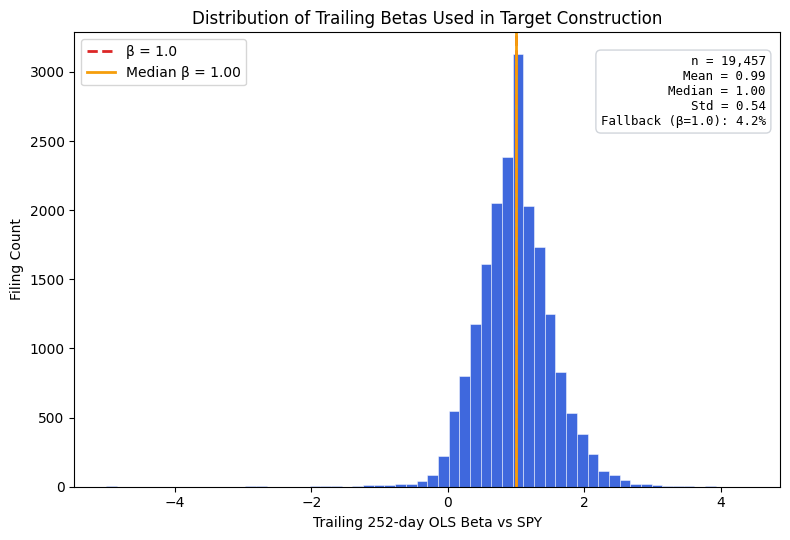

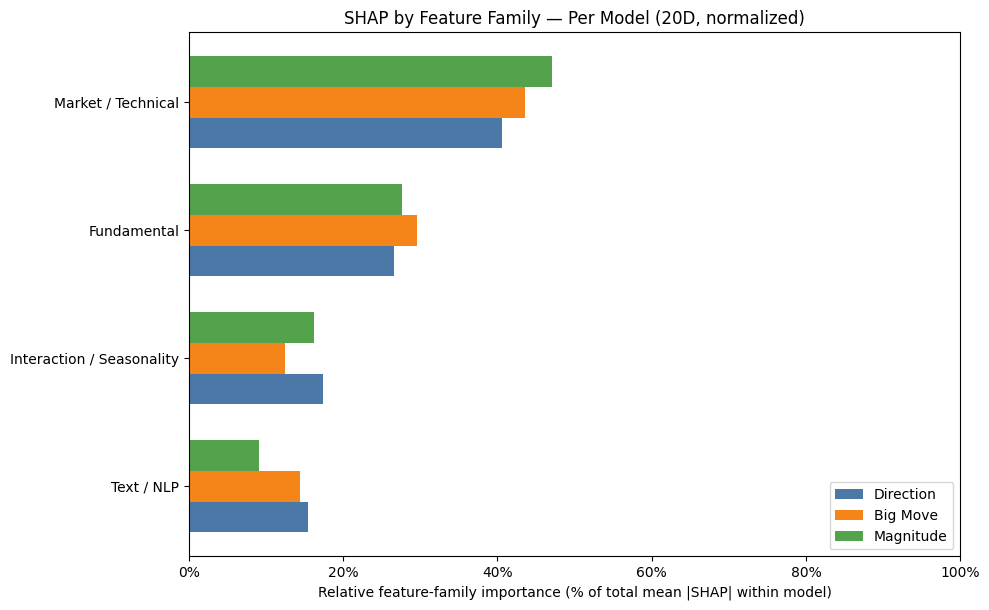

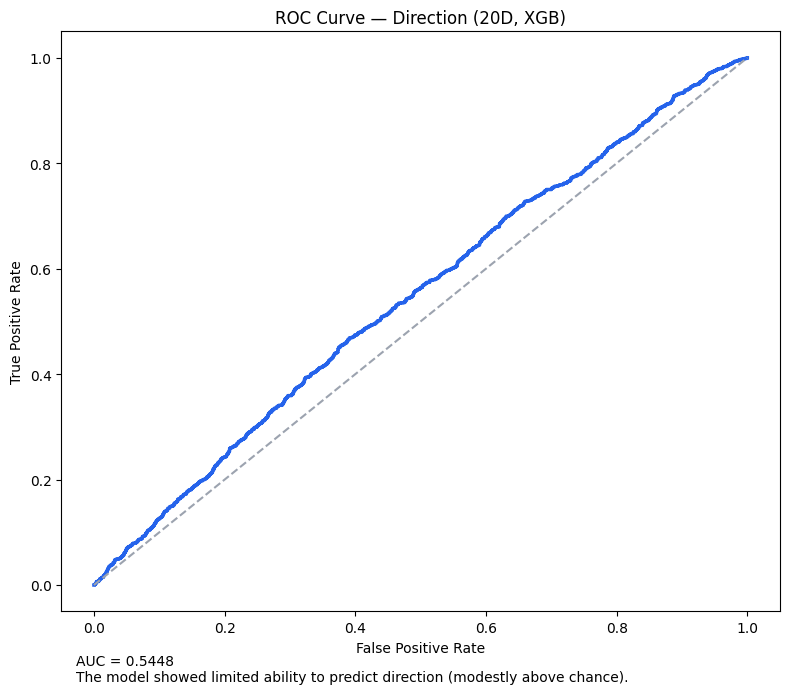

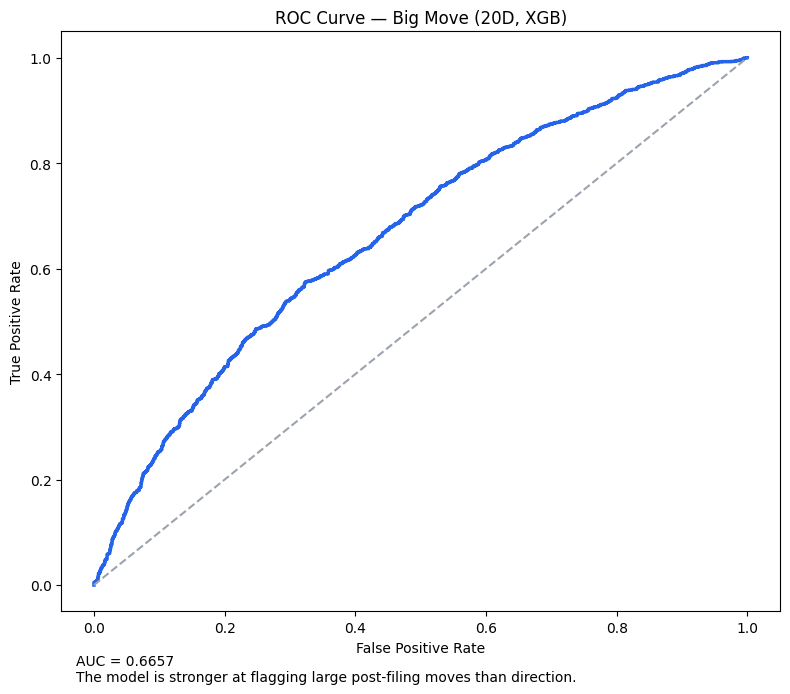

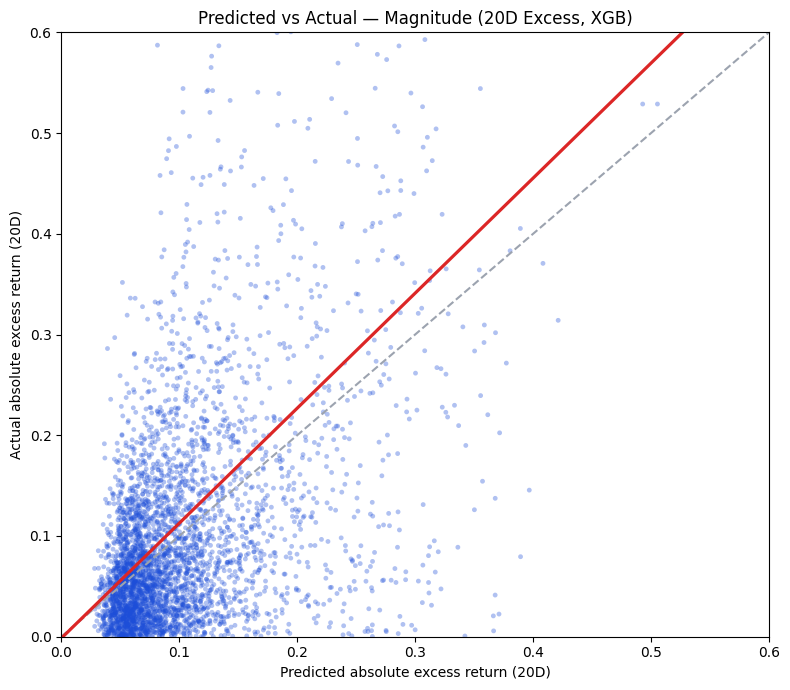

In [6]:
from pathlib import Path
import os
import pandas as pd
from sqlalchemy import create_engine

# 1) Build features from Postgres
df = _build_features_fn()
Path('data').mkdir(parents=True, exist_ok=True)
df.to_csv('data/features.csv', index=False)

# NLP feature sanity check
nlp_new = [
    'score_std_mean','score_std_max','positive_count_total','negative_count_total','neutral_count_total',
    'positive_ratio','negative_ratio','neutral_ratio','sentiment_polarity',
    'section_count','num_units_total','units_per_section'
]
for x in [x for x in nlp_new if x in df.columns]:
    nn = float(df[x].notna().mean())
    sd = float(df[x].std()) if x in df.columns else float('nan')


# 2) Snapshot returns needed for target construction (for reproducible CSV-only training)
db_url = os.getenv('DATABASE_URL') or os.getenv('POSTGRES_URL')
eng = create_engine(db_url)
need = sorted(set(df['ticker'].dropna().astype(str).tolist() + ['SPY']))
ret_snap = pd.read_sql(
    'SELECT ticker, date, ret FROM market_data_daily WHERE ticker = ANY(%(tickers)s)',
    eng,
    params={'tickers': need},
)
ret_snap['ticker'] = ret_snap['ticker'].astype(str).str.upper().str.replace('.', '-', regex=False)
ret_snap['date'] = pd.to_datetime(ret_snap['date'], errors='coerce')
ret_snap['ret'] = pd.to_numeric(ret_snap['ret'], errors='coerce')
ret_snap = ret_snap.dropna(subset=['ticker','date','ret']).sort_values(['ticker','date']).reset_index(drop=True)
ret_snap.to_csv('data/returns_snapshot.csv', index=False)

# Override load_returns to use local snapshot CSV (no DB during training)
_ret_cache = {t: g[['date','ret']].reset_index(drop=True) for t, g in ret_snap.groupby('ticker')}
def load_returns(ticker: str):
    t = str(ticker).upper().replace('.', '-')
    return _ret_cache.get(t, pd.DataFrame(columns=['date','ret']))

# Force feature loading from CSV snapshot
os.environ.pop('DATABASE_URL', None)
os.environ.pop('POSTGRES_URL', None)
DATABASE_URL = None

# 3) Headline train/eval + 4) charts
_train_eval_main_fn()
_generate_charts_fn()


In [8]:
from pathlib import Path
import re

summary_path = Path('docs/MAIN_TRAIN_EVAL_SUMMARY.md')
if not summary_path.exists():
    raise FileNotFoundError('Missing docs/MAIN_TRAIN_EVAL_SUMMARY.md. Run pipeline cell first.')

txt = summary_path.read_text(encoding='utf-8')
def grab(pattern, label):
    m = re.search(pattern, txt)
    if not m:
        raise ValueError(f'Could not find {label} in summary file')
    return float(m.group(1))

auc_dir = grab(r'\| Direction \| XGB \| AUC ([0-9.]+) \|', 'Direction AUC')
auc_big = grab(r'\| Big Move \| XGB \| AUC ([0-9.]+) \|', 'Big Move AUC')
r2_mag = grab(r'\| Magnitude \| XGB \| R² ([0-9.\-]+) \|', 'Magnitude R²')

print(f"AUC Directional (20D): {auc_dir}")
print(f"AUC Big Move (20D): {auc_big}")
print(f"R-Squared Magnitude (20D): {r2_mag}")


AUC Directional (20D): 0.5448
AUC Big Move (20D): 0.6657
R-Squared Magnitude (20D): 0.1362
